In [1]:
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
from tqdm import tqdm_notebook
#pip install pmdarima
import pmdarima as pm

ModuleNotFoundError: No module named 'pmdarima'

In [26]:
df = pd.read_csv('LG_data.csv')

# convert to datetime datatypes and create datetimeindex

df.index = pd.to_datetime(df['Date']).dt.normalize()
df = df.drop('Date', axis=1)
df.head(15)
#df['Date'].iloc[0]


,ROSNumber,Year,Month_text,Month_number,Weekday,Hour,Assistance,Rescue,WaveHeight,HighOrLowWater,EbbOrFlood,WindForce,WindForceNum
Date,,,,,,,,,,,,,
2017-10-22,LGI02056/2017,2017,October,10,Sunday,11,0,1,Unknown,Unknown,Unknown,Unknown,99
2017-08-07,LGI04589/2017,2017,July,7,Saturday,15,1,0,0.0 - 0.5m,Unknown,Unknown,Unknown,99
2017-10-22,LGI02063/2017,2017,October,10,Sunday,13,1,0,1.5 - 2.0m,Unknown,Unknown,Unknown,99
2017-10-22,LGI02063/2017,2017,October,10,Sunday,13,1,0,1.5 - 2.0m,Unknown,Unknown,Unknown,99
2017-10-22,LGI02063/2017,2017,October,10,Sunday,13,1,0,1.5 - 2.0m,Unknown,Unknown,Unknown,99
2017-04-20,LGI04063/2017,2017,April,4,Thursday,14,1,0,1.0 - 1.5m,Unknown,Flooding,Unknown,99
2017-10-07,LGI04068/2017,2017,July,7,Monday,13,1,0,0.0 - 0.5m,Unknown,Ebbing,Unknown,99
2017-12-07,LGI04601/2017,2017,July,7,Wednesday,10,1,0,0.0 - 0.5m,Unknown,Ebbing,Unknown,99
2017-07-19,LGI04066/2017,2017,July,7,Wednesday,12,1,0,Unknown,Unknown,Flooding,Unknown,99


In [30]:
df['WaveHeight'].value_counts()

0.0 - 0.5m    13858
0.5 - 1.0m     7600
1.0 - 1.5m     4500
1.5 - 2.0m     1558
Unknown         843
2.0m+           720
Name: WaveHeight, dtype: int64

In [3]:
#  removing rows from 2022

df = df.query('Year < 2022')  # removing entries from 2022 as incomplete year
df.shape

(28878, 13)

In [4]:
#  adding time period

hour = df['Hour'].map({1:'Pre-10', 2:'Pre-10', 3:'Pre-10', 4:'Pre-10', 5:'Pre-10', 6:'Pre-10', 7:'Pre-10', 8:'Pre-10', 
                                 9:'Pre-10', 10:'10-11', 11:'11-12', 12:'12-13', 13:'13-14', 14:'14-15',15:'15-16',16:'16-17',
                                 17:'17-18',18:'Post-18',19:'Post-18',20:'Post-18',21:'Post-18',22:'Post-18',23:'Post-18',
                                 24:'Post-18'})
df.insert(7, 'TimePeriod', hour)

day = df['Weekday'].map({'Monday':1, 'Tuesday':2, 'Wednesday':3, 'Thursday':4, 'Friday':5, 'Saturday':6, 'Sunday':7})
df.insert(6, 'Weekday_number', day)
df.head()

,ROSNumber,Year,Month_text,Month_number,Weekday,Hour,Weekday_number,Assistance,TimePeriod,Rescue,WaveHeight,HighOrLowWater,EbbOrFlood,WindForce,WindForceNum
Date,,,,,,,,,,,,,,,
2017-10-22,LGI02056/2017,2017,October,10,Sunday,11,7,0,11-12,1,Unknown,Unknown,Unknown,Unknown,99
2017-08-07,LGI04589/2017,2017,July,7,Saturday,15,6,1,15-16,0,0.0 - 0.5m,Unknown,Unknown,Unknown,99
2017-10-22,LGI02063/2017,2017,October,10,Sunday,13,7,1,13-14,0,1.5 - 2.0m,Unknown,Unknown,Unknown,99
2017-10-22,LGI02063/2017,2017,October,10,Sunday,13,7,1,13-14,0,1.5 - 2.0m,Unknown,Unknown,Unknown,99
2017-10-22,LGI02063/2017,2017,October,10,Sunday,13,7,1,13-14,0,1.5 - 2.0m,Unknown,Unknown,Unknown,99


In [5]:
df['count'] = 1
#df['Date'] = df['Date'].date()
df.head()

,ROSNumber,Year,Month_text,Month_number,Weekday,Hour,Weekday_number,Assistance,TimePeriod,Rescue,WaveHeight,HighOrLowWater,EbbOrFlood,WindForce,WindForceNum,count
Date,,,,,,,,,,,,,,,,
2017-10-22,LGI02056/2017,2017,October,10,Sunday,11,7,0,11-12,1,Unknown,Unknown,Unknown,Unknown,99,1
2017-08-07,LGI04589/2017,2017,July,7,Saturday,15,6,1,15-16,0,0.0 - 0.5m,Unknown,Unknown,Unknown,99,1
2017-10-22,LGI02063/2017,2017,October,10,Sunday,13,7,1,13-14,0,1.5 - 2.0m,Unknown,Unknown,Unknown,99,1
2017-10-22,LGI02063/2017,2017,October,10,Sunday,13,7,1,13-14,0,1.5 - 2.0m,Unknown,Unknown,Unknown,99,1
2017-10-22,LGI02063/2017,2017,October,10,Sunday,13,7,1,13-14,0,1.5 - 2.0m,Unknown,Unknown,Unknown,99,1


In [6]:
#  RESAMPLING 
# need to impute rows/dates where there are 0 incidents, only ~180 days a year have data

#  daily counts
df_d = df.pivot_table(values=['Assistance', 'Rescue'], index=df.index,
                      aggfunc=np.sum, fill_value=0)#.drop_duplicates()
df_d['Total'] = df_d.sum(axis=1)
df_d.index.nunique()  # checking all dates are unique
df_d_enriched = df_d.join(df[['Year', 'Month_text', 'Month_number','Weekday', 'Weekday_number']]).drop_duplicates()


#  counts per time period
df_timep = df.pivot_table(values=['Assistance', 'Rescue'], index=df[['Year','TimePeriod']],
                      aggfunc=np.sum, fill_value=0).reset_index()
df_timep['Total'] = df_timep['Assistance'] + df_timep['Rescue']

df_d_enriched.duplicated().sum()

0

In [7]:
#  Reindexing daily df to include everyday (so no gap in datetime index)

new_date_range = pd.date_range(start="2017-01-01", end="2021-12-31", freq="D")
df_d = df_d.reindex(new_date_range, fill_value=0)
df_d

,Assistance,Rescue,Total
2017-01-01,0,0,0
2017-01-02,0,0,0
2017-01-03,0,0,0
2017-01-04,3,2,5
2017-01-05,4,2,6
...,...,...,...
2021-12-27,0,0,0
2021-12-28,0,0,0
2021-12-29,0,0,0
2021-12-30,0,0,0


In [8]:
# Resampled 

df_w_mean = df_d.resample('W').mean()  # weekly mean
df_m_sum = df_d.resample('M').sum()  # monthly sum
df_m_mean = df_d.resample('M').mean()
df_4m_mean = df_d.resample('4M').mean()  #  4 monthly mean (to attempt to capture seasonality)
df_y_sum = df_d.resample('Y').sum()  # yearly sum

#  adding month column
df_m_sum['Month'] = df_m_sum.index
df_m_sum['Month'] = df_m_sum['Month'].dt.month
df_m_sum['Year'] = df_m_sum.index
df_m_sum['Year'] = df_m_sum['Year'].dt.year

df_d['Month'] = df_d.index
df_d['Month'] = df_d['Month'].dt.month

## Visualisations

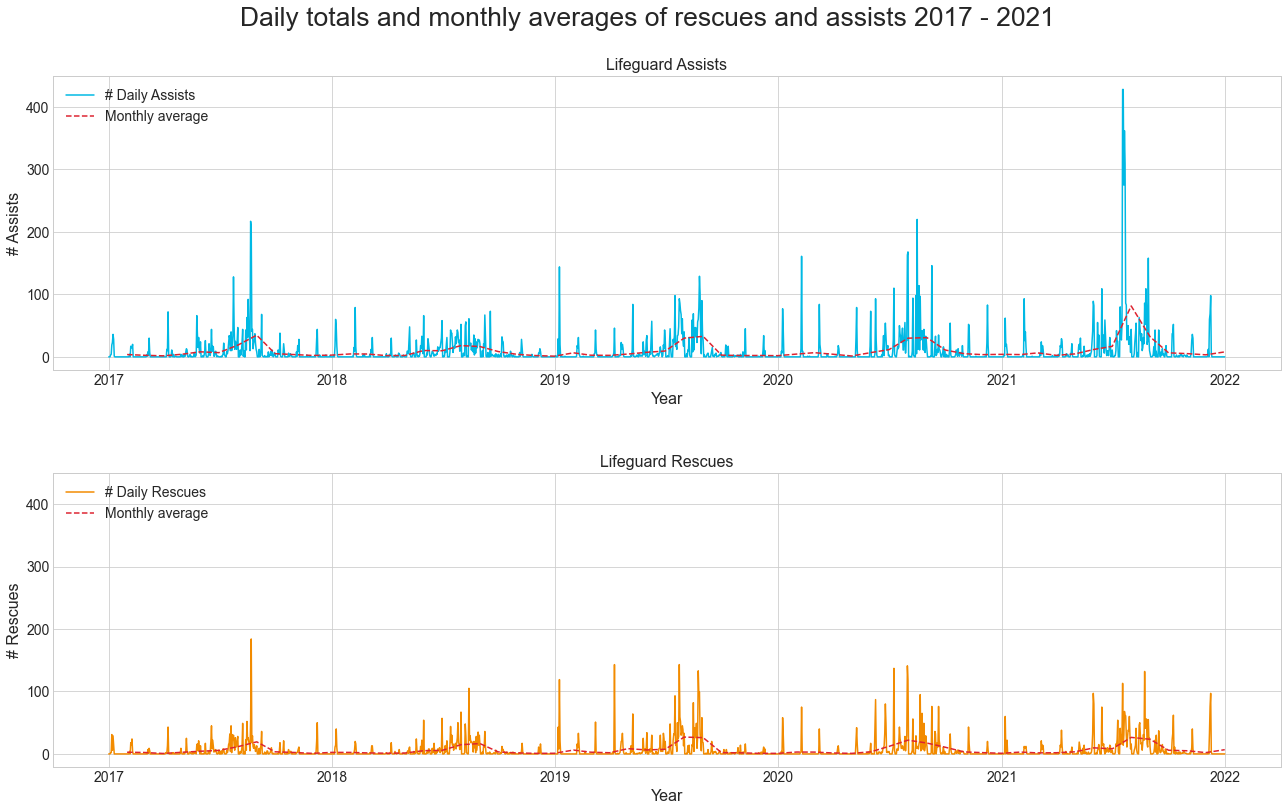

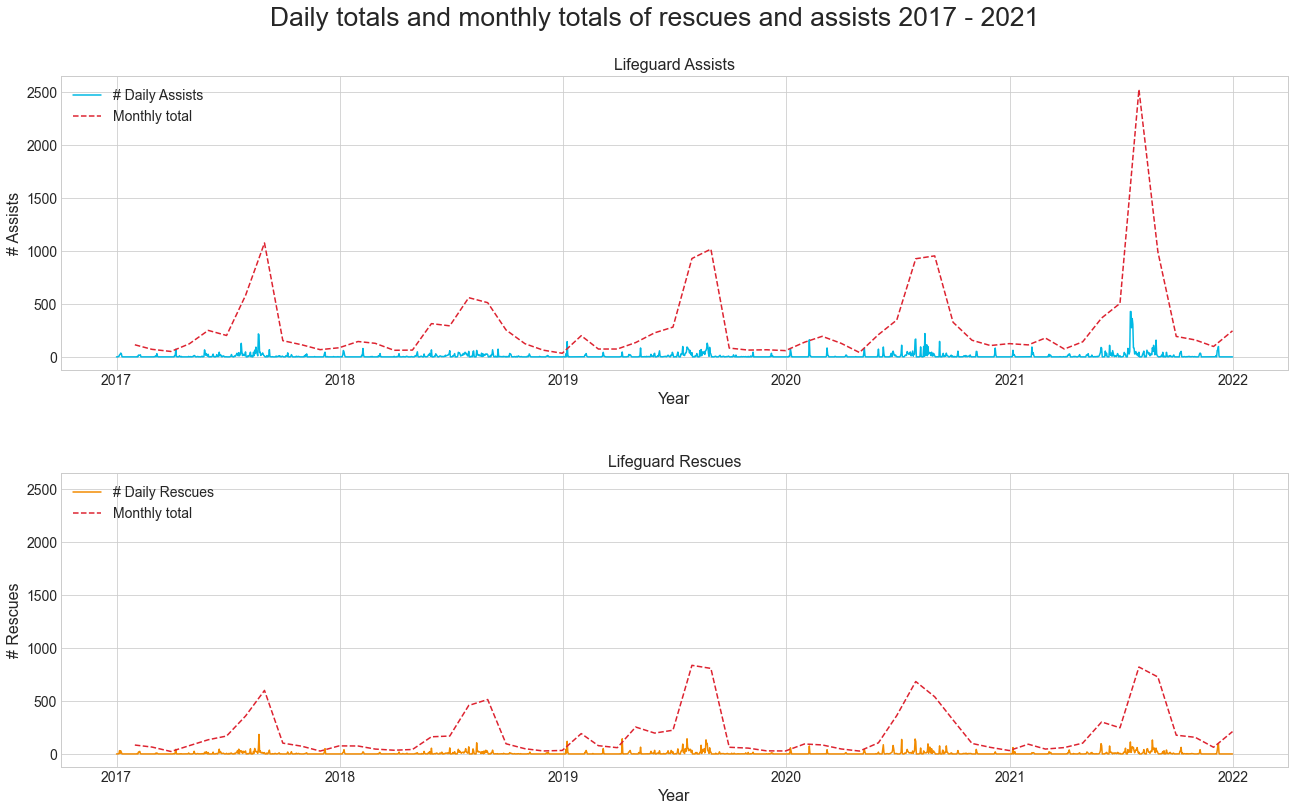

In [9]:
#  VISUALISATIONS

plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'font.size': 22})

red = '#DD2330'
d_red = '#9E1B32'
orange = '#F28B00'
d_blue = '#002663'
l_blue = '#00B9E4'

#  DAILY TOTALS AND MONTHLY AVERAGE

fig, (ax1, ax2) = plt.subplots(2,1, sharey=True)
fig.set_size_inches([22, 12])
fig.suptitle('Daily totals and monthly averages of rescues and assists 2017 - 2021')

ax1.plot(df_d.index, df_d['Assistance'], linestyle='-', c=l_blue, label='# Daily Assists')  #, alpha=0.8
#ax1.plot(df_m_sum.index, df_m_sum['Assistance'], linestyle='-', c=d_blue, label='Monthly total')
ax1.plot(df_m_mean.index, df_m_mean['Assistance'], linestyle='--', c=red, label='Monthly average')
ax1.set_xlabel('Year', fontsize=16)
ax1.set_ylabel('# Assists', fontsize=16)
ax1.set_title('Lifeguard Assists', fontsize=16)
ax1.legend(fontsize = 14, loc='upper left')

# Set tick font size
for label in (ax1.get_xticklabels() + ax1.get_yticklabels()):
    label.set_fontsize(14)
    
ax2.plot(df_d.index, df_d['Rescue'], linestyle='-', c=orange, label='# Daily Rescues') #,alpha=0.5
#ax2.plot(df_m_sum.index, df_m_sum['Rescue'], linestyle='-', c=d_red, label='Monthly total')
ax2.plot(df_m_mean.index, df_m_mean['Rescue'], linestyle='--', c=red, label='Monthly average')
ax2.set_xlabel('Year', fontsize=16)
ax2.set_ylabel('# Rescues', fontsize=16)
ax2.set_title('Lifeguard Rescues', fontsize=16)
ax2.legend(fontsize = 14, loc='upper left')
#ax2.set_ylim(np.max(df_d['Assistance']))

# Set tick font size
for label in (ax2.get_xticklabels() + ax2.get_yticklabels()):
    label.set_fontsize(14)

plt.subplots_adjust(left=0.125,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.2, 
                    hspace=0.35)
plt.show()

#  DAILY TOTALS AND MONTHLY TOTAL

fig, (ax1, ax2) = plt.subplots(2,1, sharey=True)
fig.set_size_inches([22, 12])
fig.suptitle('Daily totals and monthly totals of rescues and assists 2017 - 2021')

ax1.plot(df_d.index, df_d['Assistance'], linestyle='-', c=l_blue, label='# Daily Assists')  #, alpha=0.8
ax1.plot(df_m_sum.index, df_m_sum['Assistance'], linestyle='--', c=red, label='Monthly total')
#ax1.plot(df_m_mean.index, df_m_mean['Assistance'], linestyle='--', c=red, label='Monthly average')
ax1.set_xlabel('Year', fontsize=16)
ax1.set_ylabel('# Assists', fontsize=16)
ax1.set_title('Lifeguard Assists', fontsize=16)
ax1.legend(fontsize = 14, loc='upper left')

# Set tick font size
for label in (ax1.get_xticklabels() + ax1.get_yticklabels()):
    label.set_fontsize(14)
    
ax2.plot(df_d.index, df_d['Rescue'], linestyle='-', c=orange, label='# Daily Rescues') #,alpha=0.5
ax2.plot(df_m_sum.index, df_m_sum['Rescue'], linestyle='--', c=red, label='Monthly total')
#ax2.plot(df_m_mean.index, df_m_mean['Rescue'], linestyle='--', c=red, label='Monthly average')
ax2.set_xlabel('Year', fontsize=16)
ax2.set_ylabel('# Rescues', fontsize=16)
ax2.set_title('Lifeguard Rescues', fontsize=16)
ax2.legend(fontsize = 14, loc='upper left')
#ax2.set_ylim(np.max(df_d['Assistance']))

# Set tick font size
for label in (ax2.get_xticklabels() + ax2.get_yticklabels()):
    label.set_fontsize(14)

plt.subplots_adjust(left=0.125,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.2, 
                    hspace=0.35)
plt.show()

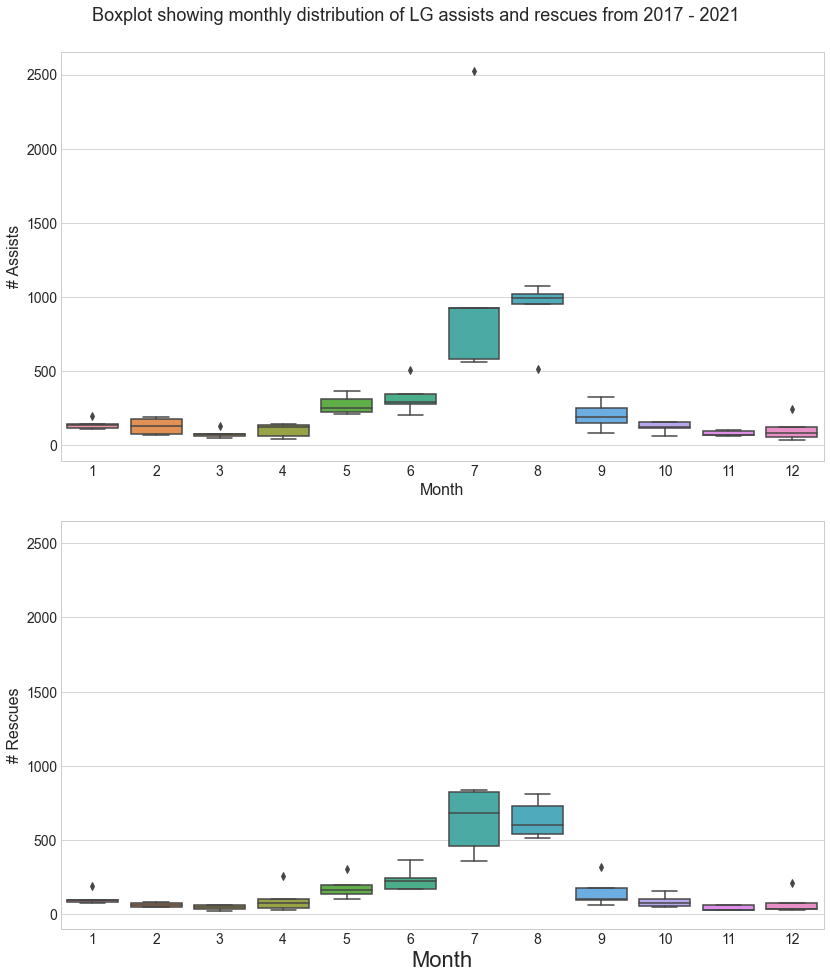

In [10]:
#  MONTHLY PLOT (ignore years)

fig, (ax1, ax2) = plt.subplots(2,1, sharey=True)
fig.set_size_inches([12, 14])
fig.suptitle('Boxplot showing monthly distribution of LG assists and rescues from 2017 - 2021', size=18)

sns.boxplot(x='Month', y='Assistance', data=df_m_sum, ax=ax1)
sns.boxplot(x='Month', y='Rescue', data=df_m_sum, ax=ax2)
ax1.set_ylabel('# Assists', fontsize=16)
ax1.set_xlabel('Month', fontsize=16)
ax2.set_ylabel('# Rescues', fontsize=16)
ax1.set_xlabel('Month', fontsize=16)

# Set tick font size
for label in (ax1.get_xticklabels() + ax1.get_yticklabels()):
    label.set_fontsize(14)
for label in (ax2.get_xticklabels() + ax2.get_yticklabels()):
    label.set_fontsize(14)

plt.tight_layout()
plt.show()

##### NOTE. The boxplots reveal there are some outliers particularly in the 'Assists' dataset (notably in 2021) which might hinder a predictive model's performance in being able to train and predict the target.

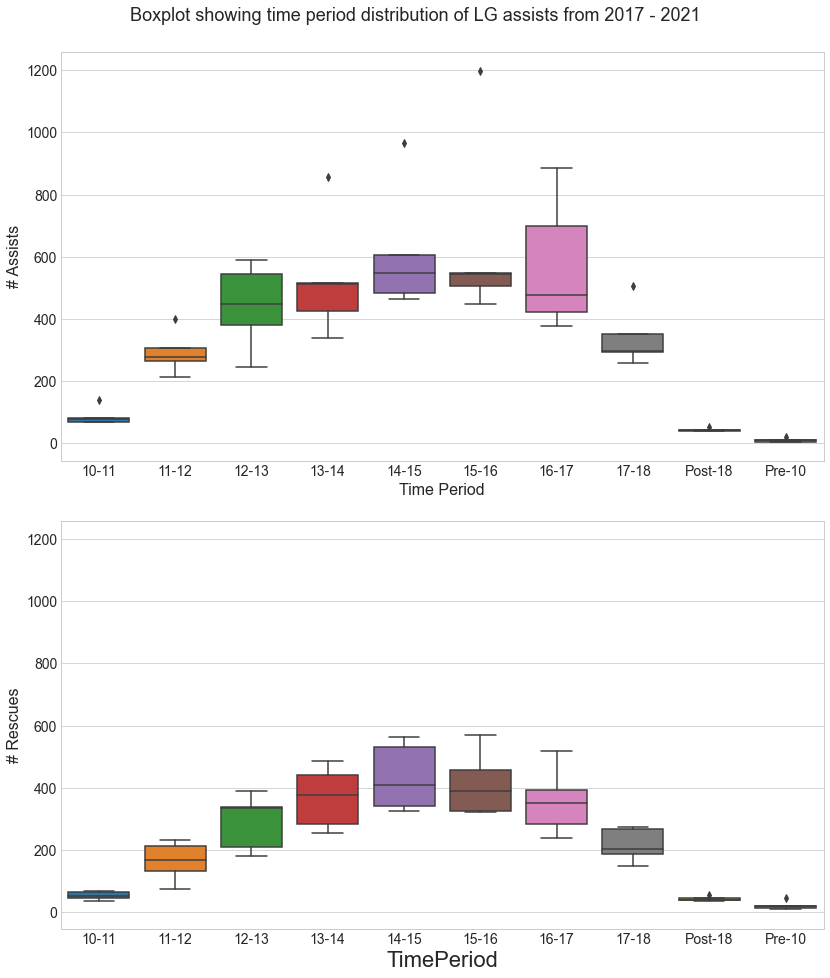

In [11]:
#  TIME PERIOD PLOT (ignore years)

df_timep

fig, (ax1, ax2) = plt.subplots(2,1, sharey=True)
fig.set_size_inches([12, 14])
fig.suptitle('Boxplot showing time period distribution of LG assists from 2017 - 2021', size=18)

sns.boxplot(x='TimePeriod', y='Assistance', data=df_timep, ax=ax1)
ax1.set_ylabel('# Assists', fontsize=16)
ax1.set_xlabel('Time Period', fontsize=16)
sns.boxplot(x='TimePeriod', y='Rescue', data=df_timep, ax=ax2)
ax2.set_ylabel('# Rescues', fontsize=16)
ax1.set_xlabel('Time Period', fontsize=16)
#ax = sns.lineplot(x='Month', y='Assistance', data=df_m_mean, hue='Year')

# Set tick font size
for label in (ax1.get_xticklabels() + ax1.get_yticklabels()):
    label.set_fontsize(14)
for label in (ax2.get_xticklabels() + ax2.get_yticklabels()):
    label.set_fontsize(14)

plt.tight_layout()
plt.show()

##### NOTE. The boxplots reveal there are some outliers in the 'Assists' dataset (notably in 2021) which might hinder a predictive model's performance in being able to train and predict the target.

##### As such, it might be easier to predict rescues over assists. 

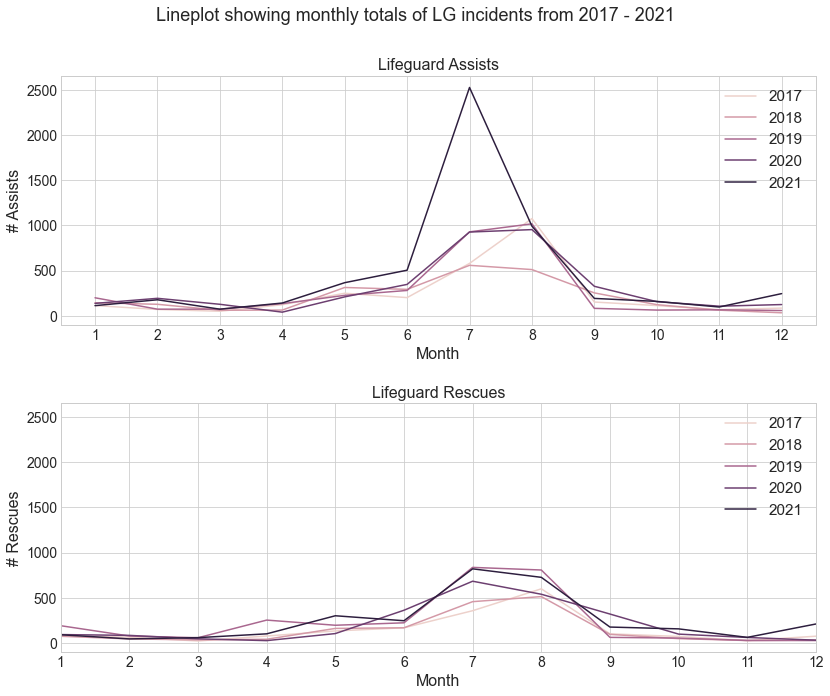

In [12]:
#  Month line plot by year
fig, (ax1, ax2) = plt.subplots(2, 1, sharey=True)
fig.set_size_inches([12, 10])
fig.suptitle('Lineplot showing monthly totals of LG incidents from 2017 - 2021', size=18)

sns.lineplot(ax=ax1, x='Month', y='Assistance', data=df_m_sum, hue='Year')
ax1.set_ylabel('# Assists', fontsize=16)
ax1.set_xlabel('Month', fontsize=16)
ax1.legend(fontsize='x-small')
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax1.set_title('Lifeguard Assists', fontsize=16)
plt.xlim(1, 12)

sns.lineplot(ax=ax2, x='Month', y='Rescue', data=df_m_sum, hue='Year')
ax2.set_ylabel('# Rescues', fontsize=16)
ax2.set_xlabel('Month', fontsize=16)
ax2.legend(fontsize='x-small')
ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(500))
ax2.set_title('Lifeguard Rescues', fontsize=16)

# Set tick font size
for label in (ax1.get_xticklabels() + ax1.get_yticklabels()):
    label.set_fontsize(14)

for label in (ax2.get_xticklabels() + ax2.get_yticklabels()):
    label.set_fontsize(14)

plt.xlim(1, 12)
plt.tight_layout()

plt.show()

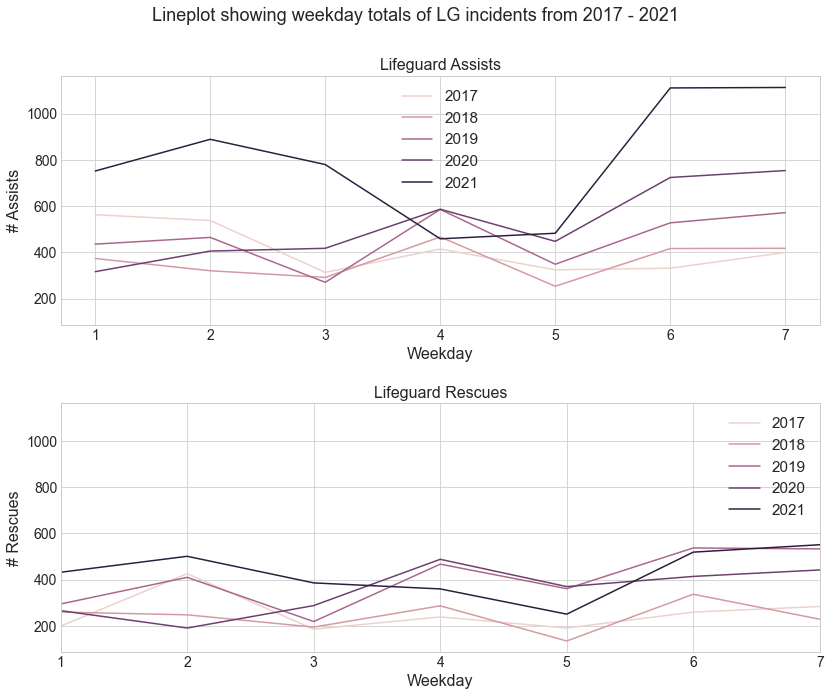

In [13]:
df_wday_sums = df_d_enriched.pivot_table(values=['Assistance', 'Rescue'], index=['Year','Weekday','Weekday_number'],
                      aggfunc=np.sum, fill_value=0).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, sharey=True)
fig.set_size_inches([12, 10])
fig.suptitle('Lineplot showing weekday totals of LG incidents from 2017 - 2021', size=18)

sns.lineplot(ax=ax1, x='Weekday_number', y='Assistance', data=df_wday_sums, hue='Year')
ax1.set_ylabel('# Assists', fontsize=16)
ax1.set_xlabel('Weekday', fontsize=16)
ax1.legend(fontsize='x-small')
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax1.set_title('Lifeguard Assists', fontsize=16)


sns.lineplot(ax=ax2, x='Weekday_number', y='Rescue', data=df_wday_sums, hue='Year')
ax2.set_ylabel('# Rescues', fontsize=16)
ax2.set_xlabel('Weekday', fontsize=16)
ax2.legend(fontsize='x-small')
ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(200))
ax2.set_title('Lifeguard Rescues', fontsize=16)

# Set tick font size
for label in (ax1.get_xticklabels() + ax1.get_yticklabels()):
    label.set_fontsize(14)

for label in (ax2.get_xticklabels() + ax2.get_yticklabels()):
    label.set_fontsize(14)
    
plt.xlim(1,7)
plt.tight_layout()
plt.show()


## Multivariate time series analysis

##### Defining models to predict the target (i.e. rescues or assists) according to various time/seasonality features and environmental features

In [14]:
#  create dummy variables
# hour, day number, month number, weekend bool, pre-season, peak season, post season
# environmental data

#  dummy seasonality variables are best for linear models (Lasso & Ridge).
#  and then another dataset with dummy variables for each month, each hour etc

In [15]:
df['HighOrLowWater'].value_counts()

Unknown    11314
Low         9947
High        7617
Name: HighOrLowWater, dtype: int64

In [16]:
df.shape

(28878, 16)

## Time series forecasting

In [24]:
#  TIME SERIES FORECASTING

#  testing for stationarity
res1 = adfuller(df['Rescue'])
res2 = adfuller(df['Assistance'])

print('RESCUES ADF statistic:', res1[0], 'p-value:%.7f' % res1[1])
print('ASSISTS ADF statistic:', res2[0], 'p-value:%.7f' % res2[1])

if res2[1] == 0.0:
        print('hello')


print(res1)
print(res2)

RESCUES ADF statistic: -16.459512190540433 p-value:0.0000000
ASSISTS ADF statistic: -23.830853145274965 p-value:0.0000000
hello
(-16.459512190540433, 2.3373300558090554e-29, 49, 28828, {'1%': -3.430576858692129, '5%': -2.8616402652601387, '10%': -2.5668233681642842}, 31315.918632222005)
(-23.830853145274965, 0.0, 24, 28853, {'1%': -3.430576662110422, '5%': -2.861640178379785, '10%': -2.566823321919924}, 31159.605937828797)


#####  p values are < 0.05 and test statistic are lower than critical value at 0.05 so we can reject null hypothesis and assume data are stationary
##### d=0

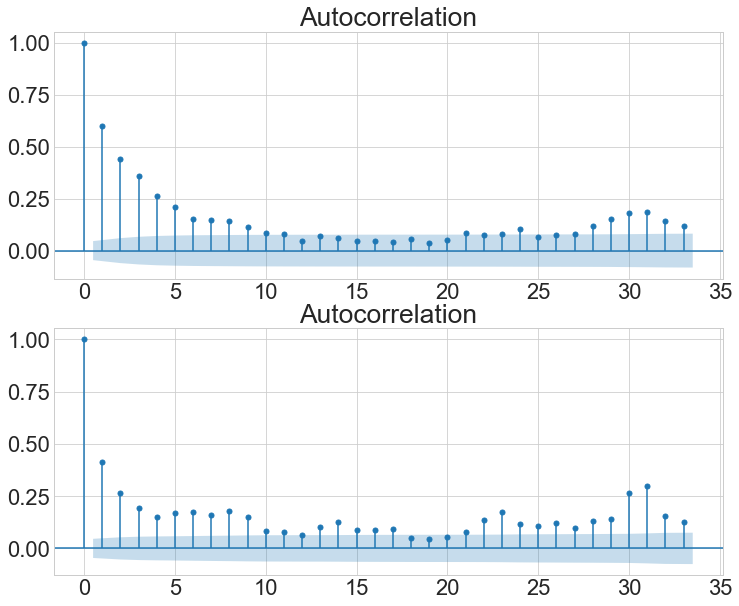

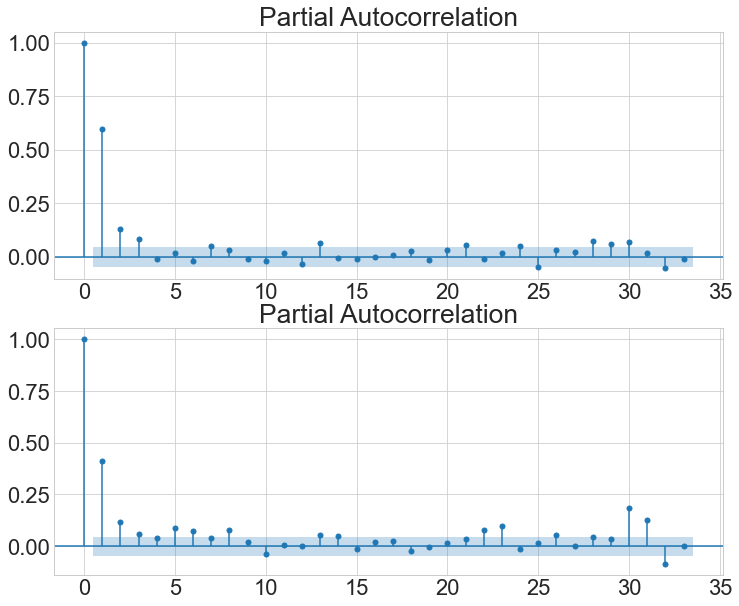

In [16]:
# defining q and p

# plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(2,1)
fig.set_size_inches([12, 10])

plot_acf(df_d['Assistance'], ax=ax1)
plot_acf(df_d['Rescue'], ax=ax2)

plt.show()

fig, (ax1, ax2) = plt.subplots(2,1)
fig.set_size_inches([12, 10])

plot_pacf(df_d['Assistance'], ax=ax1)
plot_pacf(df_d['Rescue'], ax=ax2)

plt.show()

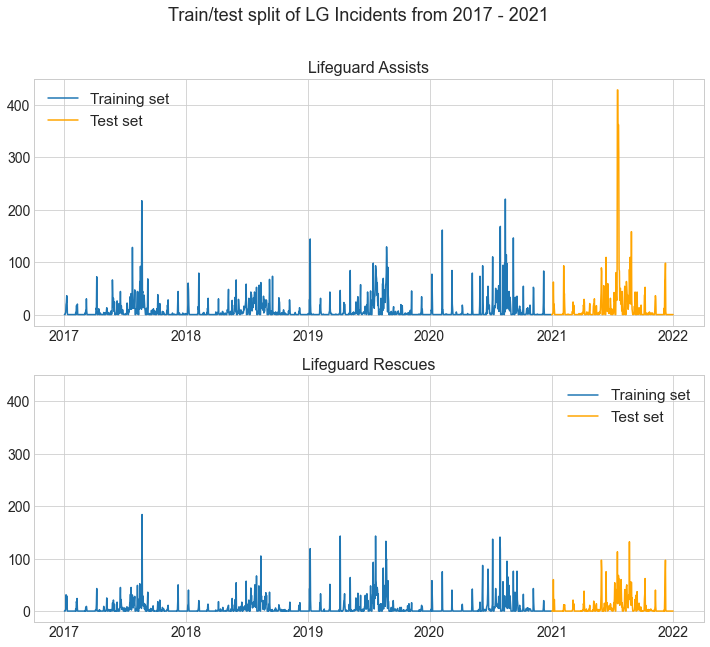

In [20]:
test_size=365  # 1 year of test data, 4 years training data

# splitting into train/test data

df_train = df_d[:-test_size]
df_test = df_d[-test_size:]

fig, (ax1, ax2) = plt.subplots(2, 1, sharey=True)
fig.set_size_inches([12, 10])
fig.suptitle('Train/test split of LG Incidents from 2017 - 2021', size=18)

ax1.plot(df_train['Assistance'], label='Training set')
ax1.plot(df_test['Assistance'], label='Test set', color='orange')
ax1.set_title('Lifeguard Assists', fontsize=16)
ax1.legend(fontsize='x-small')

ax2.plot(df_train['Rescue'], label='Training set')
ax2.plot(df_test['Rescue'], label='Test set', color='orange')
ax2.set_title('Lifeguard Rescues', fontsize=16)
ax2.legend(fontsize='x-small')

# Set tick font size
for label in (ax1.get_xticklabels() + ax1.get_yticklabels()):
    label.set_fontsize(14)

for label in (ax2.get_xticklabels() + ax2.get_yticklabels()):
    label.set_fontsize(14)

plt.show()


#### QUESTIONS? are lots of zeros in our data going to affect validity of the model?

#### no differencing required, d=0. From the above autocorrelation plots, let's start with q=5 for both and p=2

In [18]:
# Seasonal - fit stepwise auto-ARIMA
smodel_assist = pm.auto_arima(df_train['Assistance'], start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3, m=12,
                         start_P=0, seasonal=True,
                         d=None, D=1, trace=True,
                         error_action='ignore',  
                         suppress_warnings=True, 
                         stepwise=True)

smodel_assist.summary()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=3.99 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=13845.294, Time=0.05 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=13129.411, Time=0.83 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=0.93 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=13843.305, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=13691.258, Time=0.12 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=12985.554, Time=1.98 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=3.24 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=1.25 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=13177.204, Time=1.99 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=12975.022, Time=2.49 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=13121.165, Time=1.11 sec
 ARIMA(2,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=6.91 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=1.46 sec
 ARIMA(3,0,0)(2,1,0)[12] intercept   : AI

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                 1461
Model:             SARIMAX(1, 0, 1)x(2, 1, [], 12)   Log Likelihood               -6480.787
Date:                             Tue, 26 Jul 2022   AIC                          12971.575
Time:                                     14:09:57   BIC                          12997.968
Sample:                                          0   HQIC                         12981.424
                                            - 1461                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5933      0.042     13.989      0.000       0.510       0.676
ma.L1         -0.2767      0.047     -5.841      0.000      -0.369      -0.184
ar.S.L12      -0.7463      0.013    -56.970      0.000      -0.772      -0.721
ar.S.L24      -0.3113      0.012    -25.382      0.000      -0.335      -0.287
sigma2       446.8799      5.160     86.600      0.000     436.766     456.994
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):             25102.05
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.88   Skew:                             2.34
Prob(H) (two-sided):                  0.00   Kurtosis:                        22.85
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [31]:
model_assist_fit = smodel_assist.fit(disp=-1)

# Forecast
#fc, se, conf = fitted.forecast(365, alpha=0.05)  # 95% conf, predicting 365 points i.e. 1 year

TypeError: fit() missing 1 required positional argument: 'y'

In [29]:
# Seasonal - fit stepwise auto-ARIMA
smodel_rescue = pm.auto_arima(df_train['Rescue'], start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3, m=12,
                         start_P=0, seasonal=True,
                         d=None, D=1, trace=True,
                         error_action='ignore',  
                         suppress_warnings=True, 
                         stepwise=True)

smodel_rescue.summary()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=2.15 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=13051.952, Time=0.05 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=12467.164, Time=0.78 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=1.76 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=13049.962, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=12900.684, Time=0.11 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=12286.691, Time=2.05 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=7.15 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.96 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=12429.484, Time=1.67 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=12278.984, Time=2.11 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=12462.928, Time=1.05 sec
 ARIMA(2,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=7.79 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=1.23 sec
 ARIMA(3,0,0)(2,1,0)[12] intercept   : AI

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                 1461
Model:             SARIMAX(1, 0, 1)x(2, 1, [], 12)   Log Likelihood               -6133.461
Date:                             Tue, 26 Jul 2022   AIC                          12276.921
Time:                                     15:01:26   BIC                          12303.314
Sample:                                          0   HQIC                         12286.771
                                            - 1461                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5364      0.054      9.940      0.000       0.431       0.642
ma.L1         -0.2514      0.060     -4.195      0.000      -0.369      -0.134
ar.S.L12      -0.6868      0.012    -56.400      0.000      -0.711      -0.663
ar.S.L24      -0.3449      0.011    -30.837      0.000      -0.367      -0.323
sigma2       276.7829      3.009     92.000      0.000     270.886     282.680
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             35594.36
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               1.88   Skew:                             2.87
Prob(H) (two-sided):                  0.00   Kurtosis:                        26.59
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [169]:
# pre-processing
# remove nulls
# make dates the index of the dataframe
# check for missing values - there should be no missing values
# for EDA: add three (3) more columns to the data: month, day and weekday name 

# work out which value we want to predict - aggregate/sum to daily values. Need to impute rows where there is no value for that day.
#       set value to 0 for days with no incidents